# 09 — 변수 선택 재설계 (도메인 그룹핑 + 예측 최적화 + 성능 분포 정당화)

> 기말 플랜 `docs/final_presentation_plan.md` **§2.6** 구현 · 교수님 피드백 **F1·F3·F4** 응답
> **프로젝트 우선순위: 예측 1순위** — 변수 선택을 SHAP(해석)이 아니라 **성능 분포**로 정당화

## 목표
1. **(F3)** 후보를 **5개 도메인 그룹**으로 묶고 대표 변수 선정
2. **(F1)** **변수 제거가 해로운가** — 전체 vs 축소 vs 그룹대표 ablation
3. **(⑥)** 성능 분포 정당화: (a) 랜덤 서브셋 벤치마크, (b) 변수별 한계기여
4. 예측/해석 후보셋 확정 → `data/processed/features_v3_candidate.csv`

## ⭐ 순정 파이프라인 사용 (왜곡 방지)
- eval = **16d와 동일한** XGBoost(q50)·RobustScaler·3-fold walk-forward. **모델을 바꾸지 않고 변수집합만** 바꾼다.
- raw 변수 → `{var}` + `{var}__lag/__rmean/__rstd` 컬럼으로 확장 (162피처 공간).
- **162는 XGBoost 전용**. LSTM은 raw 변수를 시퀀스로 직접 학습 → 선택은 **raw 변수 레벨**(모델 무관)에서 하고, 확정 raw셋을 11에서 XGB(확장)·LSTM(raw)에 각각 적용.

## ⚠️ 정직성 가드 (plan §2.6 ⑥)
- 히스토그램은 **선택의 사후 검증용**이지 *선택 도구 아님* (최고 서브셋 cherry-pick = data snooping)
- 전체 변수집합을 1차로 두고, 분포·LOO는 보조 증거

---

## 0. 환경 설정

In [1]:
# === 의존성 체크 + import ===
import importlib.util, subprocess, sys
REQUIRED = {'xgboost':'xgboost','sklearn':'scikit-learn','matplotlib':'matplotlib','seaborn':'seaborn'}
for _imp, _pip in REQUIRED.items():
    if importlib.util.find_spec(_imp) is None:
        print(f'  Installing {_pip} ...'); subprocess.check_call([sys.executable,'-m','pip','install','-q',_pip])

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import RobustScaler
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR  = PROJECT_ROOT / 'reports' / 'figures' / 'v3'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42; np.random.seed(SEED)
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 180)
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: C:\Users\dongs\Desktop\머신러닝\머신러닝 기말 팀플\macro-bond-forecast


---

## 1. 순정 데이터 + 파이프라인 설정 (16d 동일)

`features_v2_no_leak.csv` = 14 raw(9 base + 5 파생) + 162 lag/rolling 확장 + `delta_y_bp`(타겟)

In [2]:
DF = pd.read_csv(DATA_DIR/'processed'/'features_v2_no_leak.csv',
                 index_col='date', parse_dates=['date']).sort_index()
TARGET = 'delta_y_bp'
ALL_FEATURE_COLS = [c for c in DF.columns if c != TARGET]
RAW_VARS = [c for c in ALL_FEATURE_COLS if '__' not in c]     # 14 raw (선택 단위)

# 16d 와 동일한 walk-forward fold + q50 하이퍼파라미터
FOLDS = [
    {'name':'fold1','train':('2010-01-01','2017-12-31'),'val':('2018-01-01','2019-12-31'),'test':('2020-01-01','2020-12-31')},
    {'name':'fold2','train':('2010-01-01','2019-12-31'),'val':('2020-01-01','2020-12-31'),'test':('2021-01-01','2022-12-31')},
    {'name':'fold3','train':('2010-01-01','2021-12-31'),'val':('2022-01-01','2022-12-31'),'test':('2023-01-01','2025-12-31')},
]
XGB_Q50 = dict(objective='reg:quantileerror', quantile_alpha=0.5,
               n_estimators=400, max_depth=4, learning_rate=0.05,
               early_stopping_rounds=50, tree_method='hist', random_state=42, verbosity=0)

print('전체 피처:', len(ALL_FEATURE_COLS), '| raw 변수:', len(RAW_VARS))
print('RAW_VARS:', RAW_VARS)

전체 피처: 162 | raw 변수: 14
RAW_VARS: ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']


---

## 2. 도메인 5개 그룹 정의 (F3 · plan §2.6①)

> VIF로 '제거'가 아니라, **경제 채널로 묶은 뒤 대표를 선택**. (교수님 피드백 핵심)

In [3]:
GROUPS = {
    'G1 글로벌금리':     ['us_treasury_10y','delta_us10y_t1','us_fed_funds','us_breakeven_10y'],
    'G2 한미연계/EM':    ['spread_10y_t1','dxy','delta_dxy_t1'],
    'G3 국내기간구조/정책':['kr_treasury_3y','kr_base_rate'],   # 복원후보 kr_5y/1y는 feature-eng 재실행 필요(TODO)
    'G4 위험심리':       ['vix','delta_vix_t1','sp500','kospi'],
    'G5 위기레짐':       ['crisis_dummy'],
}
REP = {'G1 글로벌금리':'delta_us10y_t1','G2 한미연계/EM':'spread_10y_t1',
       'G3 국내기간구조/정책':'kr_treasury_3y','G4 위험심리':'delta_vix_t1','G5 위기레짐':'crisis_dummy'}

rows=[]
for g,m in GROUPS.items():
    avail=[x for x in m if x in RAW_VARS]; miss=[x for x in m if x not in RAW_VARS]
    rows.append({'그룹':g,'대표':REP[g],'배정(확보)':', '.join(avail),'누락':', '.join(miss) or '-'})
print(pd.DataFrame(rows).to_string(index=False))
assigned=set(sum(GROUPS.values(),[])); print('\n그룹 미배정 raw:', [v for v in RAW_VARS if v not in assigned])

          그룹             대표                                                          배정(확보) 누락
    G1 글로벌금리 delta_us10y_t1 us_treasury_10y, delta_us10y_t1, us_fed_funds, us_breakeven_10y  -
  G2 한미연계/EM  spread_10y_t1                                spread_10y_t1, dxy, delta_dxy_t1  -
G3 국내기간구조/정책 kr_treasury_3y                                    kr_treasury_3y, kr_base_rate  -
     G4 위험심리   delta_vix_t1                                 vix, delta_vix_t1, sp500, kospi  -
     G5 위기레짐   crisis_dummy                                                    crisis_dummy  -

그룹 미배정 raw: []


---

## 3. 변수집합 정의 (F1 ablation · plan §2.6②)

> ⚠️ **사실 정정**: 실제 v2 모델(`features_v2_no_leak`)은 **9 base(kospi 포함) + 5 파생을 모두 사용** — 중간 서사의 'VIF로 8개 축소'와 달리 거의 제거하지 않았다. 따라서 ablation은 **"제거가 해로운가"**를 본다.

- **FULL**: 14 raw 전체 (= 실제 v2 모델, VIF 제거 없음)
- **REDUCED**: 저점수·공선 변수 제거 모방 — kospi(Granger p=0.57) + sp500(vix와 r=-0.73) 제거
- **GROUPREP**: 그룹 대표 5개 (최소·해석 친화)

In [4]:
SET_FULL     = list(RAW_VARS)
SET_REDUCED  = [v for v in RAW_VARS if v not in ('kospi','sp500')]
SET_GROUPREP = [REP[g] for g in GROUPS if REP[g] in RAW_VARS]

for nm, s in [('FULL', SET_FULL), ('REDUCED', SET_REDUCED), ('GROUPREP', SET_GROUPREP)]:
    print(f'{nm:9s} ({len(s):2d} raw):', s)

FULL      (14 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
REDUCED   (12 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
GROUPREP  ( 5 raw): ['delta_us10y_t1', 'spread_10y_t1', 'kr_treasury_3y', 'delta_vix_t1', 'crisis_dummy']


---

## 4. 순정 eval 함수 — raw셋 → 162공간 확장 → 16d XGBoost(q50)

> 모델·fold·스케일러 전부 16d와 동일. raw 변수집합만 바꿔 walk-forward dir acc 측정 (왜곡 없음).

In [5]:
def expand(raw_set):
    """raw 변수 → 그 변수의 base + __lag/__rmean/__rstd 컬럼 전체."""
    cols=[]
    for v in raw_set:
        cols += [c for c in ALL_FEATURE_COLS if c==v or c.startswith(v+'__')]
    return cols

def eval_canonical(raw_set, return_folds=False):
    feat = expand(raw_set)
    if not feat: return (np.nan, []) if return_folds else np.nan
    accs=[]
    for fold in FOLDS:
        sl = lambda p: DF.loc[fold[p][0]:fold[p][1]]
        Xtr, Xval, Xte = sl('train')[feat], sl('val')[feat], sl('test')[feat]
        ytr, yval, yte = sl('train')[TARGET], sl('val')[TARGET], sl('test')[TARGET]
        sc = RobustScaler().fit(Xtr)
        m = xgb.XGBRegressor(**XGB_Q50)
        m.fit(sc.transform(Xtr), ytr, eval_set=[(sc.transform(Xval), yval)], verbose=False)
        pred = m.predict(sc.transform(Xte)); yv = yte.values
        mask=(np.sign(pred)!=0)&(np.sign(yv)!=0)
        accs.append(float((np.sign(pred[mask])==np.sign(yv[mask])).mean()))
    return (float(np.mean(accs)), accs) if return_folds else float(np.mean(accs))

# 스모크 테스트 (순정 — FULL = 실제 v2 재현, 중간 ~0.61 근처여야 정상)
acc, folds = eval_canonical(SET_FULL, return_folds=True)
print('FULL dir acc (순정 q50):', round(acc,4), '| fold별:', [round(a,3) for a in folds])

FULL dir acc (순정 q50): 0.6053 | fold별: [0.585, 0.606, 0.626]


---

## 5. ablation — FULL vs REDUCED vs GROUPREP (F1)

                     집합  n_raw  n_feat  dir_acc
            FULL(실제 v2)     14     162 0.605337
REDUCED(kospi·sp500 제거)     12     138 0.582443
          GROUPREP(대표5)      5      54 0.597406


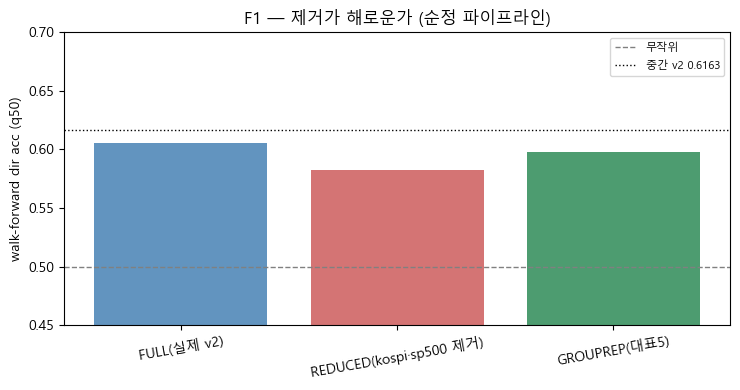

In [6]:
ablation = pd.DataFrame({
    '집합':['FULL(실제 v2)','REDUCED(kospi·sp500 제거)','GROUPREP(대표5)'],
    'n_raw':[len(SET_FULL),len(SET_REDUCED),len(SET_GROUPREP)],
    'n_feat':[len(expand(SET_FULL)),len(expand(SET_REDUCED)),len(expand(SET_GROUPREP))],
    'dir_acc':[eval_canonical(SET_FULL),eval_canonical(SET_REDUCED),eval_canonical(SET_GROUPREP)],
})
print(ablation.to_string(index=False))

fig,ax=plt.subplots(figsize=(7.5,4))
ax.bar(ablation['집합'], ablation['dir_acc'], color=['steelblue','indianred','seagreen'], alpha=0.85)
ax.axhline(0.5,color='gray',ls='--',lw=1,label='무작위'); ax.axhline(0.6163,color='black',ls=':',lw=1,label='중간 v2 0.6163')
ax.set_ylabel('walk-forward dir acc (q50)'); ax.set_ylim(0.45,0.7); ax.set_title('F1 — 제거가 해로운가 (순정 파이프라인)')
ax.legend(fontsize=8); plt.xticks(rotation=10)
plt.tight_layout(); plt.savefig(FIG_DIR/'09_ablation.png',dpi=120,bbox_inches='tight'); plt.show()
# 해석: REDUCED < FULL 이면 '제거가 해롭다'(교수님 포인트 실증). GROUPREP가 FULL에 근접하면 '소수 대표로 충분'.

---

## 6. ⑥(a) 랜덤 서브셋 벤치마크 분포 (순정, N=300)

> ⚠️ CPU 수 분 소요(순정 N회). 검증용 — 최고 서브셋을 선택에 쓰지 않음.

  50/300 ...


  100/300 ...


  150/300 ...


  200/300 ...


  250/300 ...


  300/300 ...


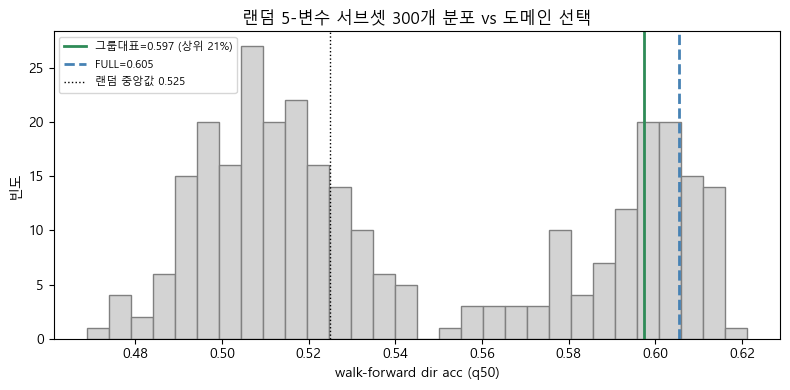

도메인 선택 GROUPREP는 랜덤 분포의 78.7 백분위


In [7]:
k = len(SET_GROUPREP)      # 부분집합 크기 = 대표 수
N = 300                    # plan 결정 (다): 순정 300회
rng = np.random.default_rng(SEED)

sub_scores=[]
for i in range(N):
    cols=list(rng.choice(RAW_VARS, size=k, replace=False))
    s=eval_canonical(cols)
    if not np.isnan(s): sub_scores.append(s)
    if (i+1)%50==0: print(f'  {i+1}/{N} ...')
sub_scores=np.array(sub_scores)

our=eval_canonical(SET_GROUPREP); full=eval_canonical(SET_FULL)
pct=float((sub_scores<our).mean()*100)

fig,ax=plt.subplots(figsize=(8,4))
ax.hist(sub_scores,bins=30,color='lightgray',edgecolor='gray')
ax.axvline(our,color='seagreen',lw=2,label=f'그룹대표={our:.3f} (상위 {100-pct:.0f}%)')
ax.axvline(full,color='steelblue',lw=2,ls='--',label=f'FULL={full:.3f}')
ax.axvline(np.median(sub_scores),color='black',ls=':',lw=1,label=f'랜덤 중앙값 {np.median(sub_scores):.3f}')
ax.set_xlabel('walk-forward dir acc (q50)'); ax.set_ylabel('빈도')
ax.set_title(f'랜덤 {k}-변수 서브셋 {len(sub_scores)}개 분포 vs 도메인 선택'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'09_random_subset_hist.png',dpi=120,bbox_inches='tight'); plt.show()
print(f'도메인 선택 GROUPREP는 랜덤 분포의 {pct:.1f} 백분위')

---

## 7. ⑥(b) 변수별 한계 기여 (LOO)

전체(FULL)에서 raw 1개씩 제거 → dir acc 하락폭 = 그 변수의 한계 가치.

FULL dir acc: 0.6053
              변수  제거시 dir_acc   Δ(기여)
  delta_us10y_t1       0.4998  0.1055
             vix       0.5777  0.0276
  kr_treasury_3y       0.5848  0.0206
    us_fed_funds       0.5924  0.0129
   spread_10y_t1       0.5969  0.0084
    kr_base_rate       0.6008  0.0045
           sp500       0.6020  0.0033
us_breakeven_10y       0.6049  0.0005
    crisis_dummy       0.6053  0.0000
    delta_dxy_t1       0.6104 -0.0051
 us_treasury_10y       0.6112 -0.0058
             dxy       0.6119 -0.0065
    delta_vix_t1       0.6124 -0.0070
           kospi       0.6137 -0.0083


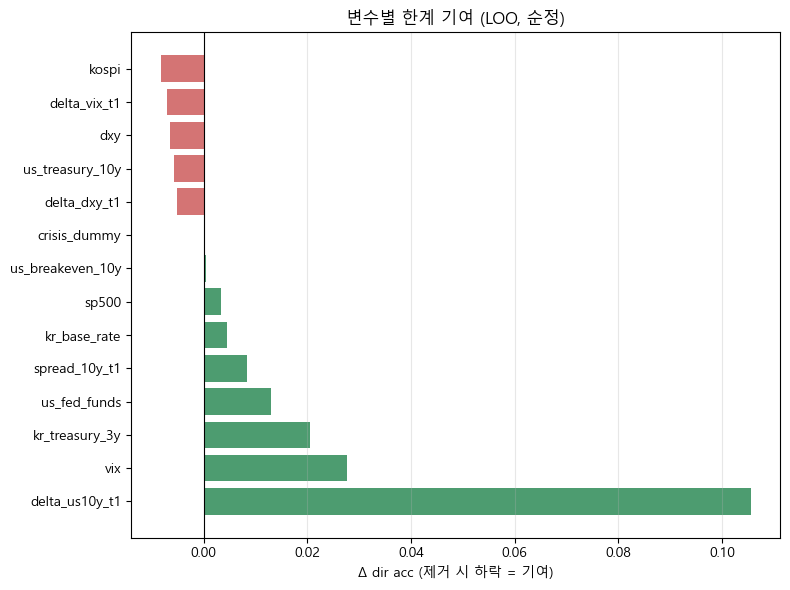

In [8]:
base_acc = eval_canonical(SET_FULL)
loo=[]
for v in SET_FULL:
    acc=eval_canonical([x for x in SET_FULL if x!=v])
    loo.append({'변수':v,'제거시 dir_acc':round(acc,4),'Δ(기여)':round(base_acc-acc,4)})
loo_df=pd.DataFrame(loo).sort_values('Δ(기여)',ascending=False)
print('FULL dir acc:',round(base_acc,4)); print(loo_df.to_string(index=False))

fig,ax=plt.subplots(figsize=(8,6))
colors=['seagreen' if v>=0 else 'indianred' for v in loo_df['Δ(기여)']]
ax.barh(loo_df['변수'], loo_df['Δ(기여)'], color=colors, alpha=0.85)
ax.axvline(0,color='black',lw=0.8); ax.set_xlabel('Δ dir acc (제거 시 하락 = 기여)')
ax.set_title('변수별 한계 기여 (LOO, 순정)'); ax.grid(alpha=0.3,axis='x')
plt.tight_layout(); plt.savefig(FIG_DIR/'09_loo.png',dpi=120,bbox_inches='tight'); plt.show()
# Δ<0 변수(제거가 오히려 도움)는 해석 주의: 공선 파트너에 기여가 흡수됐을 수 있음(교수님 F2).

---

## 8. 결론 — 예측/해석 후보셋 확정

> 도메인 + ablation + 분포 종합. 분포 최고점 cherry-pick 금지.

In [9]:
# TODO: 위 결과 보고 최종 확정 (1차안 placeholder)
PRED_SET   = SET_FULL      # 예측용: 제거 안 함(제거가 해로우면) — 11에서 full 재검증
INTERP_SET = SET_GROUPREP  # 해석용: 그룹 대표

print('PRED_SET  (%d raw):'%len(PRED_SET), PRED_SET)
print('INTERP_SET(%d raw):'%len(INTERP_SET), INTERP_SET)

# 확정 raw셋의 162-확장 컬럼 + 타겟 저장 (11에서 사용)
out_cols = expand(PRED_SET) + [TARGET]
out = DF[out_cols].copy()
out_path = DATA_DIR/'processed'/'features_v3_candidate.csv'
out.to_csv(out_path)
print('\n💾 저장:', out_path.relative_to(PROJECT_ROOT), out.shape, '| raw:', PRED_SET)

PRED_SET  (14 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
INTERP_SET(5 raw): ['delta_us10y_t1', 'spread_10y_t1', 'kr_treasury_3y', 'delta_vix_t1', 'crisis_dummy']



💾 저장: data\processed\features_v3_candidate.csv (3725, 163) | raw: ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']


---

## 9. 다음 단계

- [ ] §5 ablation / §6 분포 / §7 LOO 검토 후 **PRED_SET·INTERP_SET 최종 확정**
- [ ] (선택) kr_5y/1y 진짜 VIF-복원 테스트 → feature-eng 재실행 필요 (현재 파일엔 kr_3y만 확장됨)
- [ ] `11_v3_results.ipynb` — 확정 raw셋으로 **XGBoost(162확장)·LSTM(raw 시퀀스)** full 재실행 + DM test
- [ ] `12_pred_interval_v3.ipynb` — v3 예측구간(§3.1)

### 정직성 메모
- eval은 16d와 동일 모델(q50·fold·scaler) — 변수집합만 변경(왜곡 없음)
- 분포·LOO는 검증용, 선택은 도메인 1차
- 실제 v2가 kospi 포함 9 base를 다 썼다는 사실 → 발표 변수선택 서사 정정 필요(plan §2.6)
